In [1]:
import pm4py
import pandas as pd
import numpy as np
from pm4py.visualization.footprints import visualizer as fp_visualizer
from pm4py.algo.discovery.footprints import algorithm as footprints_discovery
from pm4py.algo.evaluation.replay_fitness import algorithm as replay_fitness_evaluator
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator

In [2]:
log = pm4py.read_xes("../data/BPI Challenge 2017.xes.gz")

/Users/felixhauptmann/ProM-Assignment-Group-C/.venv/lib/python3.13/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [3]:
log_noised = pm4py.read_xes("../data/noised.xes.gz")

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [4]:
log_recovered = pm4py.read_xes("../data/recovered.xes.gz")

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [5]:
df = pm4py.convert_to_dataframe(log)
df_noised = pm4py.convert_to_dataframe(log_noised)
df_recovered = pm4py.convert_to_dataframe(log_recovered)

In [6]:
dfg, start_activities, end_activities = pm4py.discover_dfg(log)
dfg_noised, start_activities_noised, end_activities_noised = pm4py.discover_dfg(log_noised)
dfg_recovered, start_activities_recovered, end_activities_recovered = pm4py.discover_dfg(log_recovered)

## a) Footprint Matrix

### 1. Clean log

In [7]:
footprints = footprints_discovery.apply(log)

In [8]:
footprints["sequence"]

{('A_Accepted', 'O_Create Offer'),
 ('A_Complete', 'A_Cancelled'),
 ('A_Complete', 'A_Denied'),
 ('A_Complete', 'O_Cancelled'),
 ('A_Complete', 'O_Create Offer'),
 ('A_Complete', 'O_Sent (mail and online)'),
 ('A_Complete', 'O_Sent (online only)'),
 ('A_Complete', 'W_Shortened completion '),
 ('A_Concept', 'A_Accepted'),
 ('A_Concept', 'W_Shortened completion '),
 ('A_Create Application', 'A_Concept'),
 ('A_Create Application', 'A_Submitted'),
 ('A_Create Application', 'W_Complete application'),
 ('A_Denied', 'O_Refused'),
 ('A_Incomplete', 'A_Denied'),
 ('A_Incomplete', 'O_Accepted'),
 ('A_Incomplete', 'O_Create Offer'),
 ('A_Incomplete', 'O_Returned'),
 ('A_Incomplete', 'W_Shortened completion '),
 ('A_Pending', 'W_Call after offers'),
 ('A_Pending', 'W_Call incomplete files'),
 ('A_Pending', 'W_Validate application'),
 ('A_Submitted', 'W_Handle leads'),
 ('A_Validating', 'A_Cancelled'),
 ('A_Validating', 'A_Denied'),
 ('A_Validating', 'O_Accepted'),
 ('A_Validating', 'O_Create Offer

In [9]:
footprints["parallel"]

{('A_Accepted', 'W_Complete application'),
 ('A_Accepted', 'W_Shortened completion '),
 ('A_Cancelled', 'O_Cancelled'),
 ('A_Cancelled', 'W_Call after offers'),
 ('A_Cancelled', 'W_Call incomplete files'),
 ('A_Cancelled', 'W_Complete application'),
 ('A_Cancelled', 'W_Validate application'),
 ('A_Complete', 'W_Call after offers'),
 ('A_Concept', 'W_Complete application'),
 ('A_Denied', 'W_Call after offers'),
 ('A_Denied', 'W_Call incomplete files'),
 ('A_Denied', 'W_Complete application'),
 ('A_Denied', 'W_Validate application'),
 ('A_Incomplete', 'W_Call incomplete files'),
 ('A_Validating', 'W_Validate application'),
 ('O_Cancelled', 'A_Cancelled'),
 ('O_Cancelled', 'O_Cancelled'),
 ('O_Cancelled', 'O_Returned'),
 ('O_Cancelled', 'O_Sent (mail and online)'),
 ('O_Cancelled', 'O_Sent (online only)'),
 ('O_Cancelled', 'W_Call after offers'),
 ('O_Cancelled', 'W_Call incomplete files'),
 ('O_Cancelled', 'W_Complete application'),
 ('O_Cancelled', 'W_Validate application'),
 ('O_Create

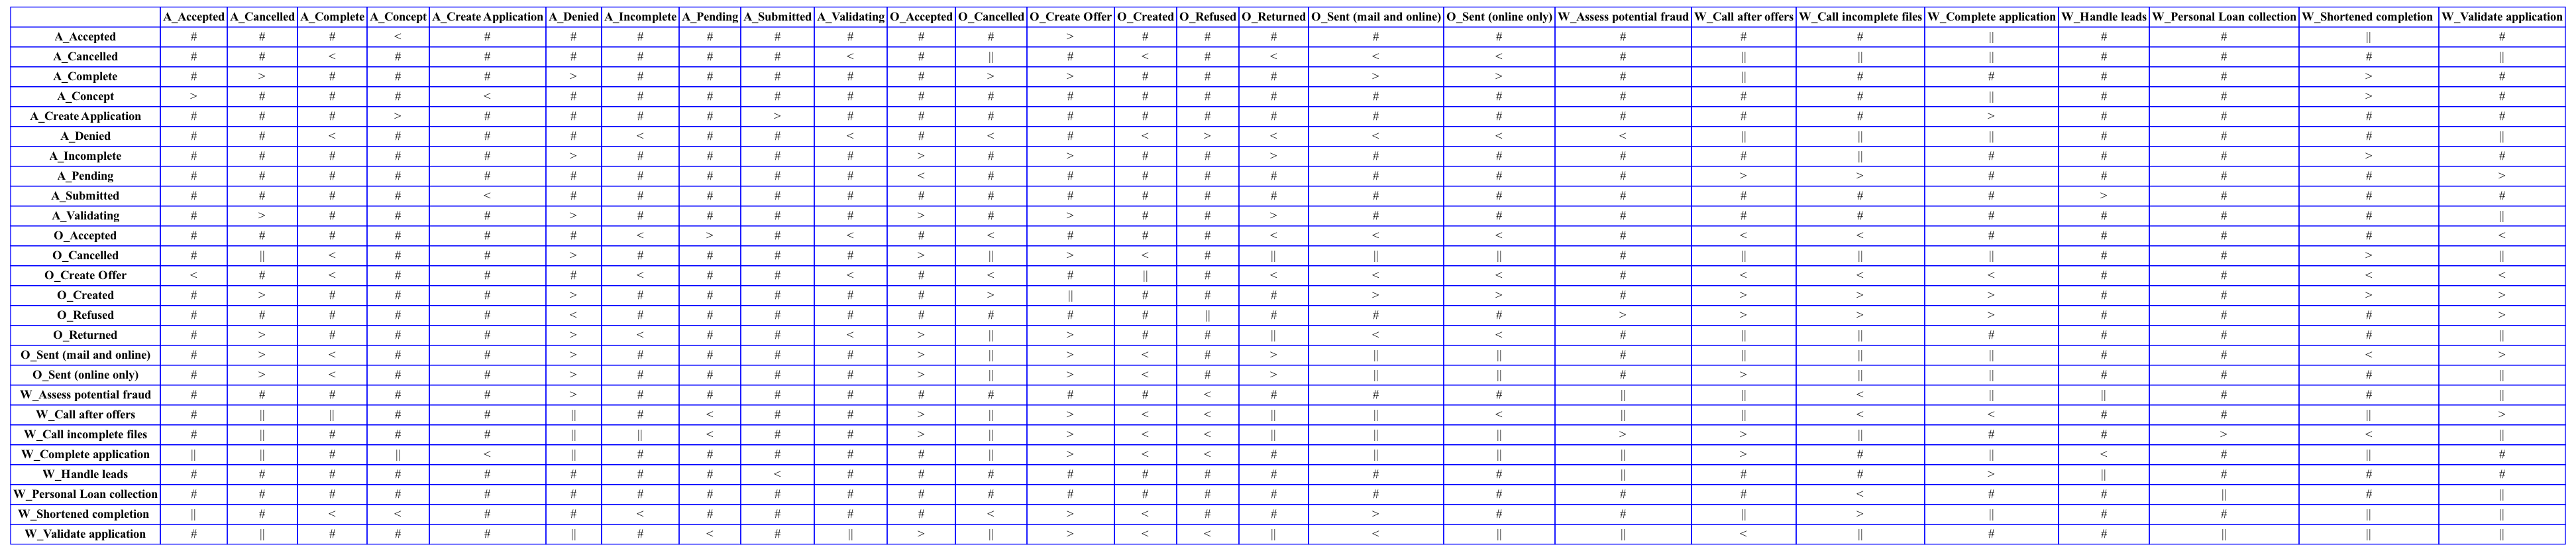

In [10]:
gviz_footprints = fp_visualizer.apply(footprints)
fp_visualizer.view(gviz_footprints)

#### Specific Trace

Confirms Footprint Matrix:

**Example for sequence (< / >):**

A_Create Application > A_Submitted

A_Submitted < A_Create Application

**Example for parallel (||):**

A_Complete || W_Call after offers

W_Call after offers || A_Complete

**Example for no relation (#):**

In [15]:
case_list = list(df['case:concept:name'].unique())

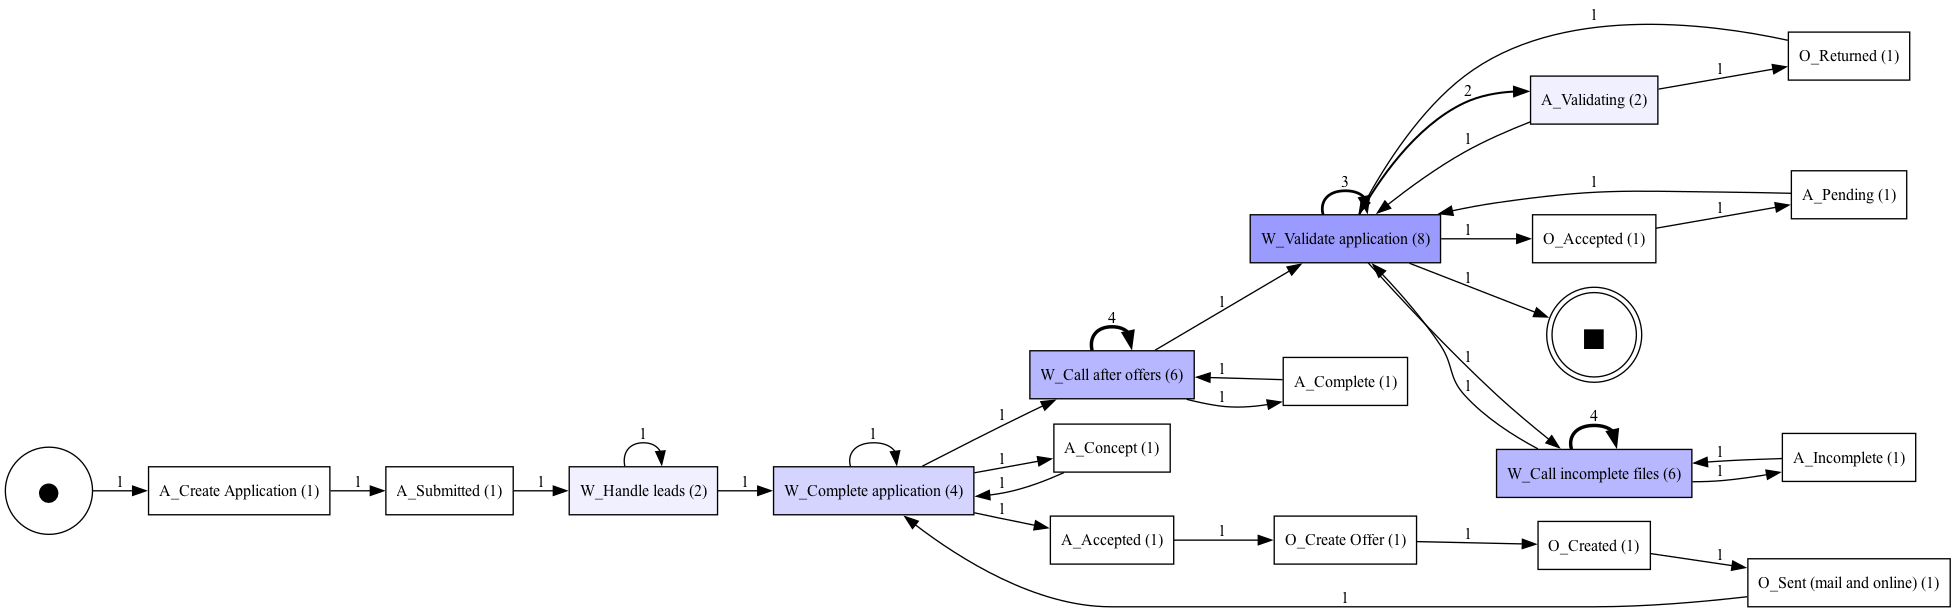

In [17]:
dfg_trace, start_activities_trace, end_activities_trace = pm4py.discover_dfg(df[df['case:concept:name'].isin(case_list[:1])])
pm4py.view_dfg(dfg_trace, start_activities_trace, end_activities_trace)

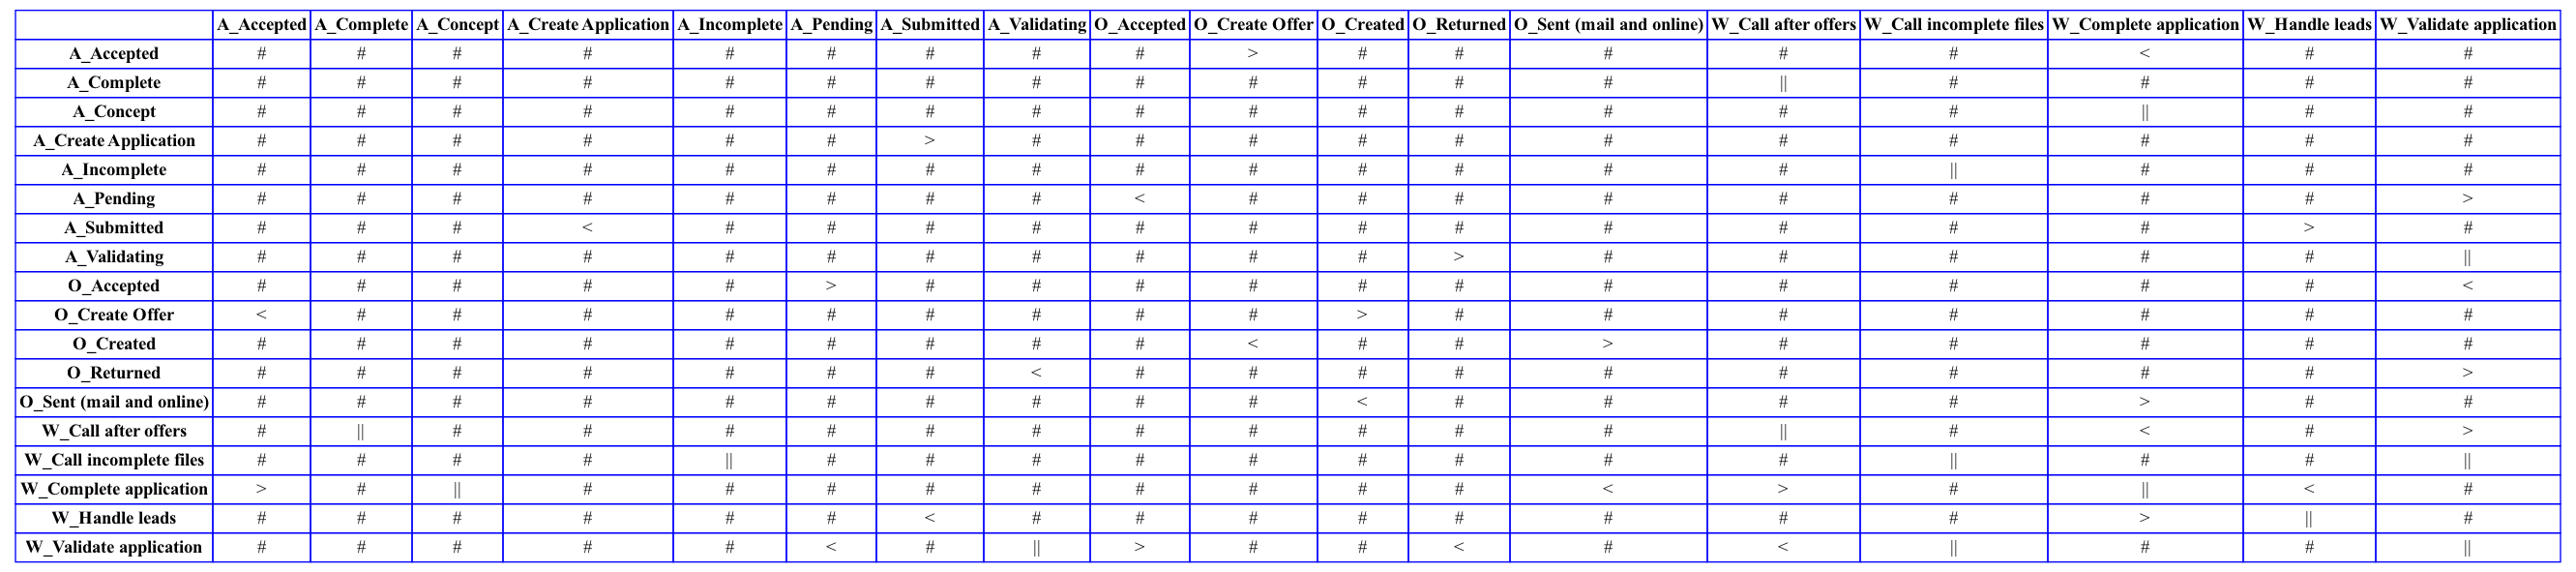

In [18]:
footprints_trace = footprints_discovery.apply(df[df['case:concept:name'].isin(case_list[:1])])
gviz_footprints_trace = fp_visualizer.apply(footprints_trace)
fp_visualizer.view(gviz_footprints_trace)

In [19]:
#('A_Create Application', 'A_Submitted') from sequence list
print(dfg.get(("A_Create Application", "A_Submitted"), 0))
print(dfg.get(("A_Submitted", "A_Create Application"), 0))

20423
0


In [20]:
# ('A_Complete', 'W_Call after offers')
print(dfg.get(("A_Complete", "W_Call after offers"), 0))
print(dfg.get(("W_Call after offers", "A_Complete"), 0))

30396
31362


In [21]:
# get activities from first trace

case_id = case_list[0]

trace_df = df[df["case:concept:name"] == case_id]

trace_activities = trace_df["concept:name"].tolist()

trace_activities

['A_Create Application',
 'A_Submitted',
 'W_Handle leads',
 'W_Handle leads',
 'W_Complete application',
 'A_Concept',
 'W_Complete application',
 'W_Complete application',
 'A_Accepted',
 'O_Create Offer',
 'O_Created',
 'O_Sent (mail and online)',
 'W_Complete application',
 'W_Call after offers',
 'W_Call after offers',
 'A_Complete',
 'W_Call after offers',
 'W_Call after offers',
 'W_Call after offers',
 'W_Call after offers',
 'W_Validate application',
 'W_Validate application',
 'A_Validating',
 'O_Returned',
 'W_Validate application',
 'W_Validate application',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'A_Incomplete',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Validate application',
 'W_Validate application',
 'A_Validating',
 'W_Validate application',
 'O_Accepted',
 'A_Pending',
 'W_Validate application']

In [22]:
# find activities with no relation
def find_hash_relation_example(dfg, activities):
    for a in activities:
        for b in activities:
            if a == b:
                continue

            if dfg.get((a, b), 0) == 0 and dfg.get((b, a), 0) == 0:
                return a, b

    return None

In [23]:
find_hash_relation_example(dfg_trace, trace_activities)

('A_Create Application', 'W_Handle leads')

In [24]:
print(dfg.get(("A_Create Application", "W_Handle leads"), 0))
print(dfg.get(("W_Handle leads", "A_Create Application"), 0))

0
0


### 2. Noised Log

In [25]:
footprints_noised = footprints_discovery.apply(log_noised)

In [26]:
footprints_noised["sequence"]

{('W_Call after offers',
  'W_Call after offers - Incident No. Application_461433493'),
 ('W_Call after offers',
  'W_Call after offers - Incident No. Application_23849387'),
 ('W_Assess pot. fraud', 'O_Accepted'),
 ('W_Call after offers', 'O_Returned - Incident No. Application_946540113'),
 ('W_Finalize application',
  'W_Complete application - Incident No. Application_2128172349'),
 ('O_Returned - Incident No. Application_1939318281',
  'W_Call incomplete files'),
 ('W_Handle leads - Incident No. Application_961455404',
  'W_Finish application'),
 ('A_Complete - Incident No. Application_1251582652', 'W_Call after offers'),
 ('W_Call incomplete files',
  'W_Call incomplete files - Incident No. Application_1842271625'),
 ('O_Sent (mail and online) - Incident No. Application_757550982',
  'W_Call after offers'),
 ('A_Denied', 'O_Ref. - Incident No. Application_1357377502'),
 ('W_Call incomplete files - Incident No. Application_1769646803',
  'W_Call incomplete files'),
 ('A_Incomplete',

In [27]:
footprints_noised["parallel"]

{('A_Acc.', 'W_Complete appl.'),
 ('A_Acc.', 'W_Complete application'),
 ('A_Acc.', 'W_Finalize application'),
 ('A_Acc.', 'W_Finish application'),
 ('A_Acc.', 'W_Shortened completion '),
 ('A_Accepted', 'W_Complete appl.'),
 ('A_Accepted', 'W_Complete application'),
 ('A_Accepted', 'W_Finalize application'),
 ('A_Accepted', 'W_Finish application'),
 ('A_Accepted', 'W_Shortened completion '),
 ('A_Canc.', 'O_Cancelled'),
 ('A_Canc.', 'W_Call after offers'),
 ('A_Canc.', 'W_Call incomplete files'),
 ('A_Canc.', 'W_Complete application'),
 ('A_Cancelled', 'O_Canc.'),
 ('A_Cancelled', 'O_Cancelled'),
 ('A_Cancelled', 'W_Call after offers'),
 ('A_Cancelled', 'W_Call after ofrs.'),
 ('A_Cancelled', 'W_Call incompl. files'),
 ('A_Cancelled', 'W_Call incomplete files'),
 ('A_Cancelled', 'W_Complete application'),
 ('A_Cancelled', 'W_Finalize application'),
 ('A_Cancelled', 'W_Finish application'),
 ('A_Comp.', 'W_Call after offers'),
 ('A_Comp.', 'W_Call after ofrs.'),
 ('A_Comp. - Incident N

In [28]:
from IPython.display import SVG, display

gviz_footprints_noised = fp_visualizer.apply(footprints_noised)
display(SVG(gviz_footprints_noised.pipe(format="svg")))

#### Specific Trace

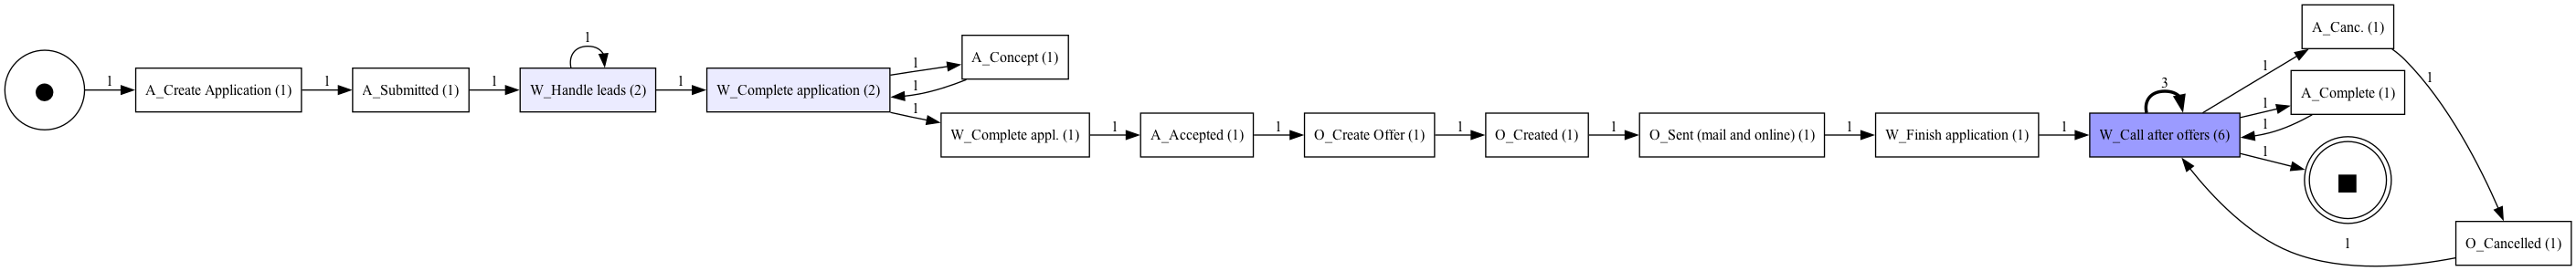

In [29]:
case_list_noised = list(df_noised['case:concept:name'].unique())

df_noised_trace = df_noised[
    df_noised['case:concept:name'].isin(case_list_noised[:1])
]

dfg_trace_noised, start_activities_trace_noised, end_activities_trace_noised = pm4py.discover_dfg(df_noised_trace)

pm4py.view_dfg(
    dfg_trace_noised,
    start_activities_trace_noised,
    end_activities_trace_noised
)

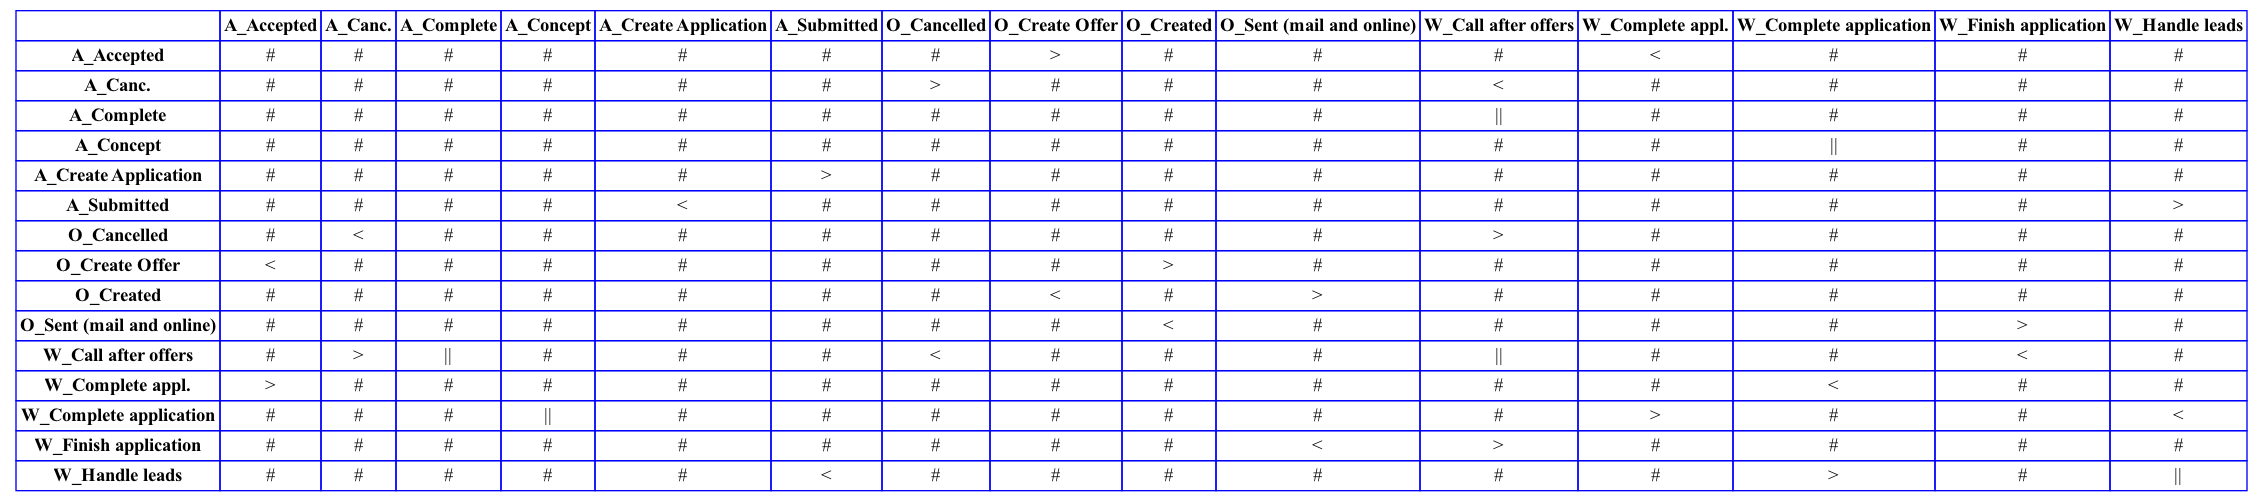

In [30]:
df_noised_trace = df_noised[
    df_noised['case:concept:name'].isin(case_list_noised[:1])
]

footprints_trace_noised = footprints_discovery.apply(df_noised_trace)

gviz_footprints_trace_noised = fp_visualizer.apply(footprints_trace_noised)
fp_visualizer.view(gviz_footprints_trace_noised)

In [31]:
# get activities from first trace

case_id_noised = case_list_noised[0]

trace_df_noised = df_noised[df_noised["case:concept:name"] == case_id_noised]

trace_activities_noised = trace_df_noised["concept:name"].tolist()

trace_activities_noised

['A_Create Application',
 'A_Submitted',
 'W_Handle leads',
 'W_Handle leads',
 'W_Complete application',
 'A_Concept',
 'W_Complete application',
 'W_Complete appl.',
 'A_Accepted',
 'O_Create Offer',
 'O_Created',
 'O_Sent (mail and online)',
 'W_Finish application',
 'W_Call after offers',
 'W_Call after offers',
 'A_Complete',
 'W_Call after offers',
 'W_Call after offers',
 'W_Call after offers',
 'A_Canc.',
 'O_Cancelled',
 'W_Call after offers']

In [32]:
find_hash_relation_example(dfg_trace_noised, trace_activities_noised)

('A_Create Application', 'W_Handle leads')

In [33]:
print(dfg_noised.get(("A_Create Application", "W_Handle leads"),0))
print(dfg_noised.get(("W_Handle leads", "A_Create Application"),0))

0
0


### 3. Recovered Log

In [34]:
footprints_recovered = footprints_discovery.apply(log_recovered)

In [35]:
footprints_recovered["sequence"]

{('A_Accepted', 'O_Create Offer'),
 ('A_Complete', 'A_Cancelled'),
 ('A_Complete', 'O_Create Offer'),
 ('A_Concept', 'A_Accepted'),
 ('A_Create Application', 'A_Submitted'),
 ('A_Create Application', 'W_Complete application'),
 ('A_Denied', 'O_Refused'),
 ('A_Submitted', 'W_Handle leads'),
 ('A_Validating', 'A_Cancelled'),
 ('A_Validating', 'A_Denied'),
 ('A_Validating', 'A_Incomplete'),
 ('A_Validating', 'A_Pending'),
 ('A_Validating', 'O_Create Offer'),
 ('A_Validating', 'O_Returned'),
 ('O_Accepted', 'O_Cancelled'),
 ('O_Accepted', 'W_Call after offers'),
 ('O_Cancelled', 'A_Complete'),
 ('O_Cancelled', 'A_Denied'),
 ('O_Cancelled', 'A_Incomplete'),
 ('O_Cancelled', 'A_Pending'),
 ('O_Cancelled', 'O_Create Offer'),
 ('O_Cancelled', 'W_Shortened completion'),
 ('O_Created', 'A_Cancelled'),
 ('O_Created', 'A_Complete'),
 ('O_Created', 'A_Denied'),
 ('O_Created', 'A_Incomplete'),
 ('O_Created', 'O_Cancelled'),
 ('O_Created', 'O_Sent (mail and online)'),
 ('O_Created', 'O_Sent (online o

In [36]:
footprints_recovered["parallel"]

{('A_Accepted', 'W_Complete application'),
 ('A_Accepted', 'W_Shortened completion'),
 ('A_Cancelled', 'O_Cancelled'),
 ('A_Cancelled', 'W_Call after offers'),
 ('A_Cancelled', 'W_Call incomplete files'),
 ('A_Cancelled', 'W_Complete application'),
 ('A_Cancelled', 'W_Validate application'),
 ('A_Complete', 'O_Sent (mail and online)'),
 ('A_Complete', 'O_Sent (online only)'),
 ('A_Complete', 'W_Call after offers'),
 ('A_Complete', 'W_Complete application'),
 ('A_Concept', 'A_Create Application'),
 ('A_Concept', 'W_Complete application'),
 ('A_Concept', 'W_Handle leads'),
 ('A_Create Application', 'A_Concept'),
 ('A_Denied', 'W_Call after offers'),
 ('A_Denied', 'W_Call incomplete files'),
 ('A_Denied', 'W_Complete application'),
 ('A_Denied', 'W_Validate application'),
 ('A_Incomplete', 'O_Returned'),
 ('A_Incomplete', 'W_Call incomplete files'),
 ('A_Incomplete', 'W_Validate application'),
 ('A_Pending', 'O_Accepted'),
 ('A_Pending', 'W_Call incomplete files'),
 ('A_Pending', 'W_Valid

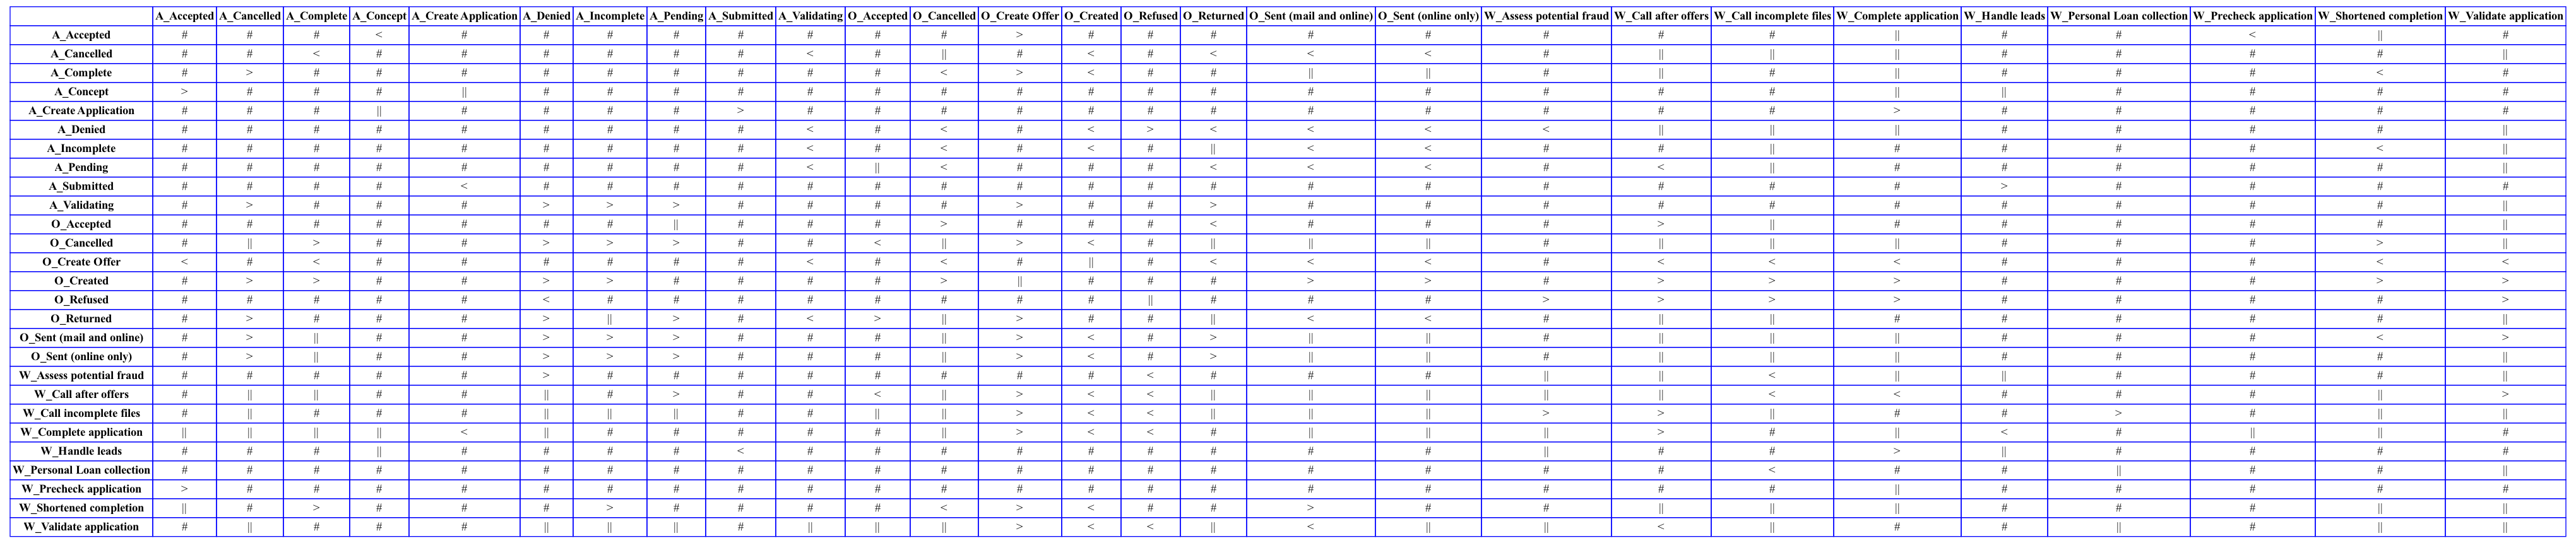

In [37]:
gviz_footprints_recovered = fp_visualizer.apply(footprints_recovered)
fp_visualizer.view(gviz_footprints_recovered)

#### Specific Trace

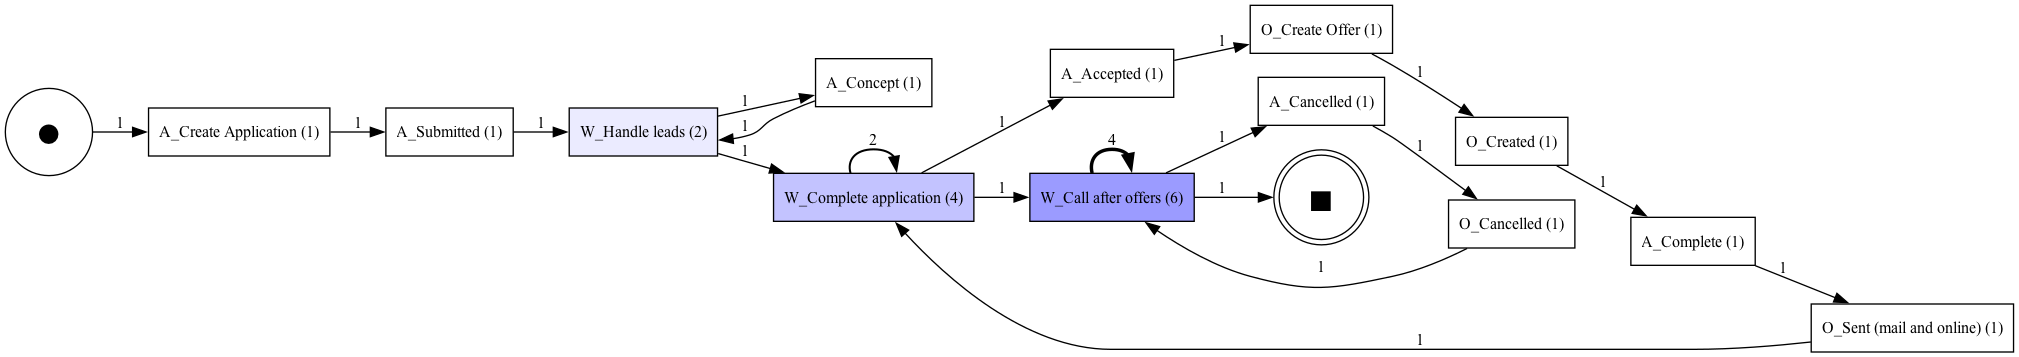

In [38]:
case_list_recovered = list(df_recovered['case:concept:name'].unique())

df_recovered_trace = df_recovered[
    df_recovered['case:concept:name'].isin(case_list_recovered[:1])
]

dfg_trace_recovered, start_activities_trace_recovered, end_activities_trace_recovered = pm4py.discover_dfg(df_recovered_trace)

pm4py.view_dfg(
    dfg_trace_recovered,
    start_activities_trace_recovered,
    end_activities_trace_recovered
)

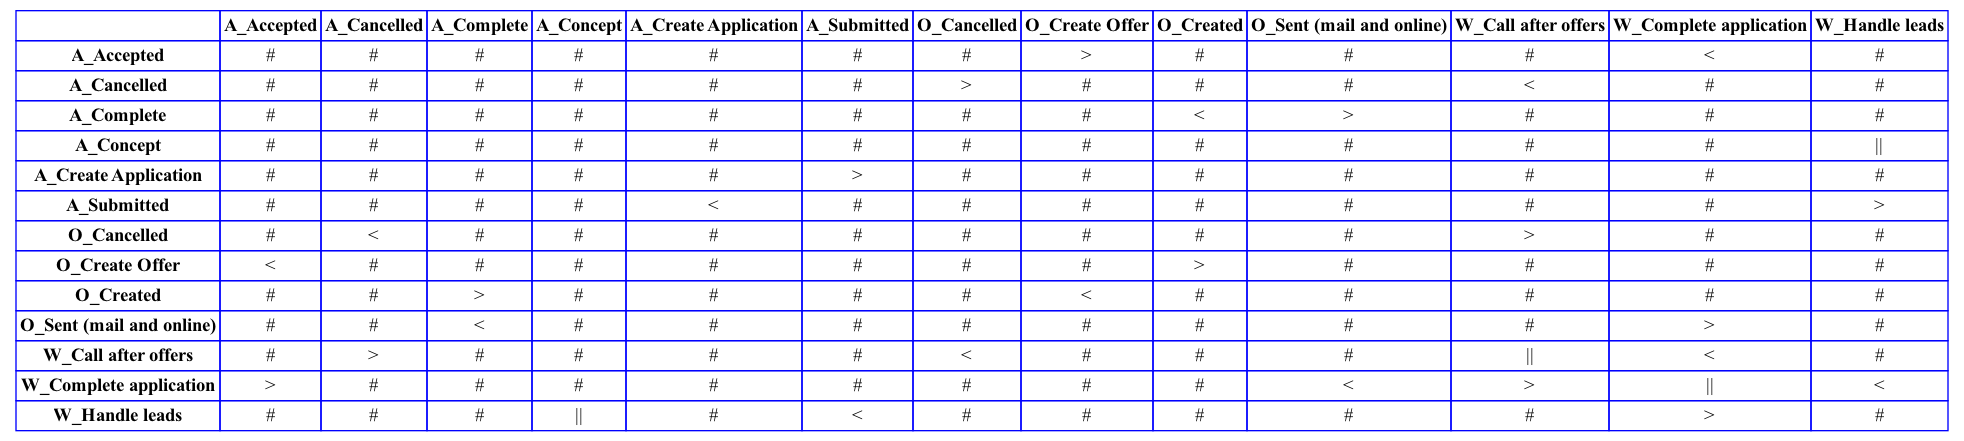

In [39]:
df_recovered_trace = df_recovered[
    df_recovered['case:concept:name'].isin(case_list_recovered[:1])
]

footprints_trace_recovered = footprints_discovery.apply(df_recovered_trace)

gviz_footprints_trace_recovered = fp_visualizer.apply(footprints_trace_recovered)
fp_visualizer.view(gviz_footprints_trace_recovered)

In [40]:
# get activities from first trace

case_id_recovered = case_list_recovered[0]

trace_df_recovered = df_recovered[df_recovered["case:concept:name"] == case_id_recovered]

trace_activities_recovered = trace_df_recovered["concept:name"].tolist()

trace_activities_recovered

['A_Create Application',
 'A_Submitted',
 'W_Handle leads',
 'A_Concept',
 'W_Handle leads',
 'W_Complete application',
 'W_Complete application',
 'W_Complete application',
 'A_Accepted',
 'O_Create Offer',
 'O_Created',
 'A_Complete',
 'O_Sent (mail and online)',
 'W_Complete application',
 'W_Call after offers',
 'W_Call after offers',
 'W_Call after offers',
 'W_Call after offers',
 'W_Call after offers',
 'A_Cancelled',
 'O_Cancelled',
 'W_Call after offers']

In [41]:
find_hash_relation_example(dfg_trace_recovered, trace_activities_recovered)

('A_Create Application', 'W_Handle leads')

In [42]:
print(dfg_recovered.get(("A_Create Application", "W_Handle leads"),0))
print(dfg_recovered.get(("W_Handle leads", "A_Create Application"),0))

0
0


## b) alpha-miner

In [43]:
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.visualization.petri_net import visualizer as pn_visualizer

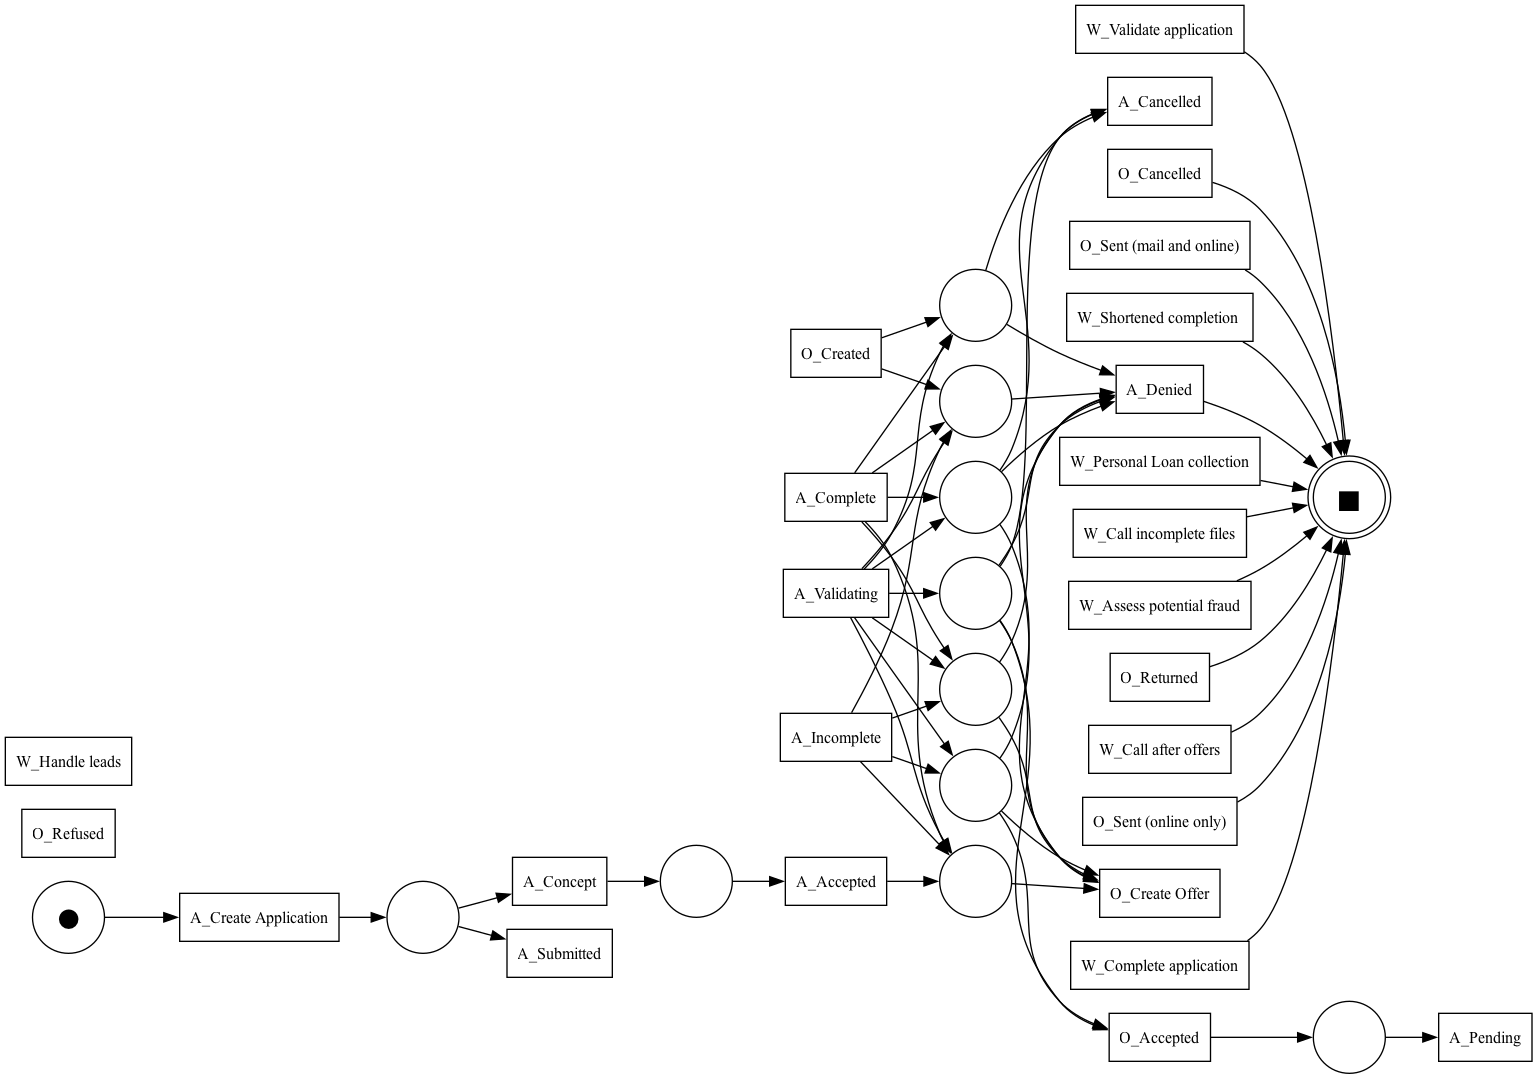

In [44]:
net_clean, initial_marking_clean, final_marking_clean = alpha_miner.apply(df)

gviz_net_clean = pn_visualizer.apply(
    net_clean,
    initial_marking_clean,
    final_marking_clean
)

pn_visualizer.view(gviz_net_clean)

In [45]:
net_noised, initial_marking_noised, final_marking_noised = alpha_miner.apply(df_noised)

gviz_net_noised = pn_visualizer.apply(
    net_noised,
    initial_marking_noised,
    final_marking_noised
)

pn_visualizer.view(gviz_net_noised)

KeyboardInterrupt: 

In [57]:
sample_size = 5000

sample_case_ids = case_list[:sample_size]

df_sample = df[
    df["case:concept:name"].isin(sample_case_ids)
].sort_values(["case:concept:name", "time:timestamp"])

df_noised_sample = df_noised[
    df_noised["case:concept:name"].isin(sample_case_ids)
].sort_values(["case:concept:name", "time:timestamp"])

df_recovered_sample = df_recovered[
    df_recovered["case:concept:name"].isin(sample_case_ids)
].sort_values(["case:concept:name", "time:timestamp"])

In [60]:
sample_size = 5000

sample_case_ids = (
    df["case:concept:name"]
    .drop_duplicates()
    .sample(n=sample_size, random_state=42)
    .tolist()
)

df_sample = df[
    df["case:concept:name"].isin(sample_case_ids)
].sort_values(["case:concept:name", "time:timestamp"])

df_noised_sample = df_noised[
    df_noised["case:concept:name"].isin(sample_case_ids)
].sort_values(["case:concept:name", "time:timestamp"])

df_recovered_sample = df_recovered[
    df_recovered["case:concept:name"].isin(sample_case_ids)
].sort_values(["case:concept:name", "time:timestamp"])

In [61]:
net_sample, im_sample, fm_sample = alpha_miner.apply(df_sample)

In [62]:
net_noised_sample, im_noised_sample, fm_noised_sample = alpha_miner.apply(df_noised_sample)

In [63]:
net_recovered_sample, im_recovered_sample, fm_recovered_sample = alpha_miner.apply(df_recovered_sample)

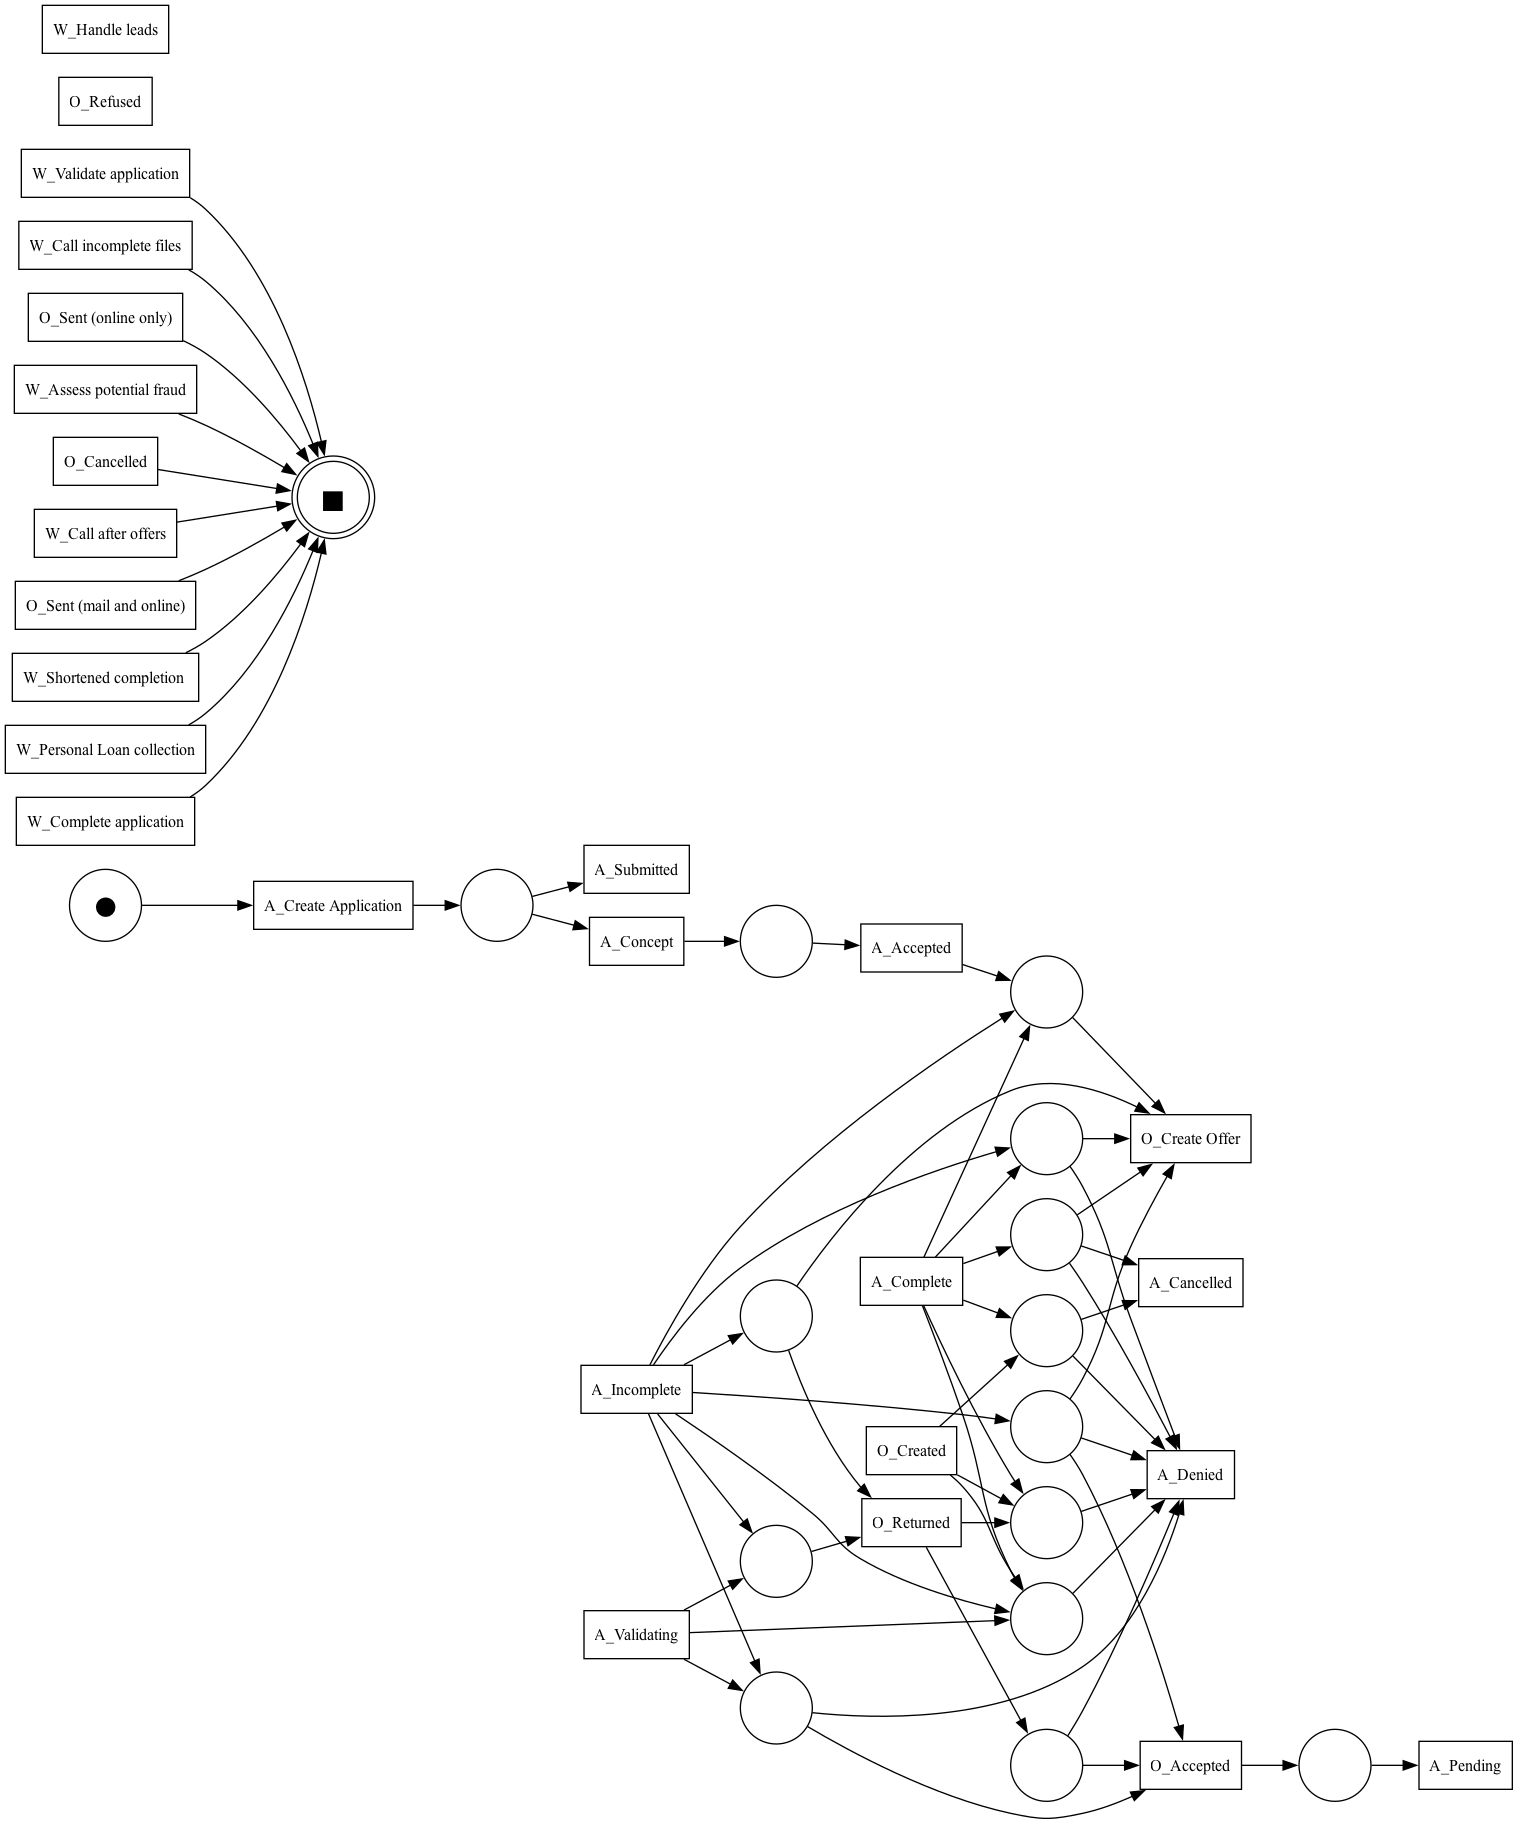

In [64]:
gviz_net_sample = pn_visualizer.apply(net_sample, im_sample, fm_sample)
pn_visualizer.view(gviz_net_sample)

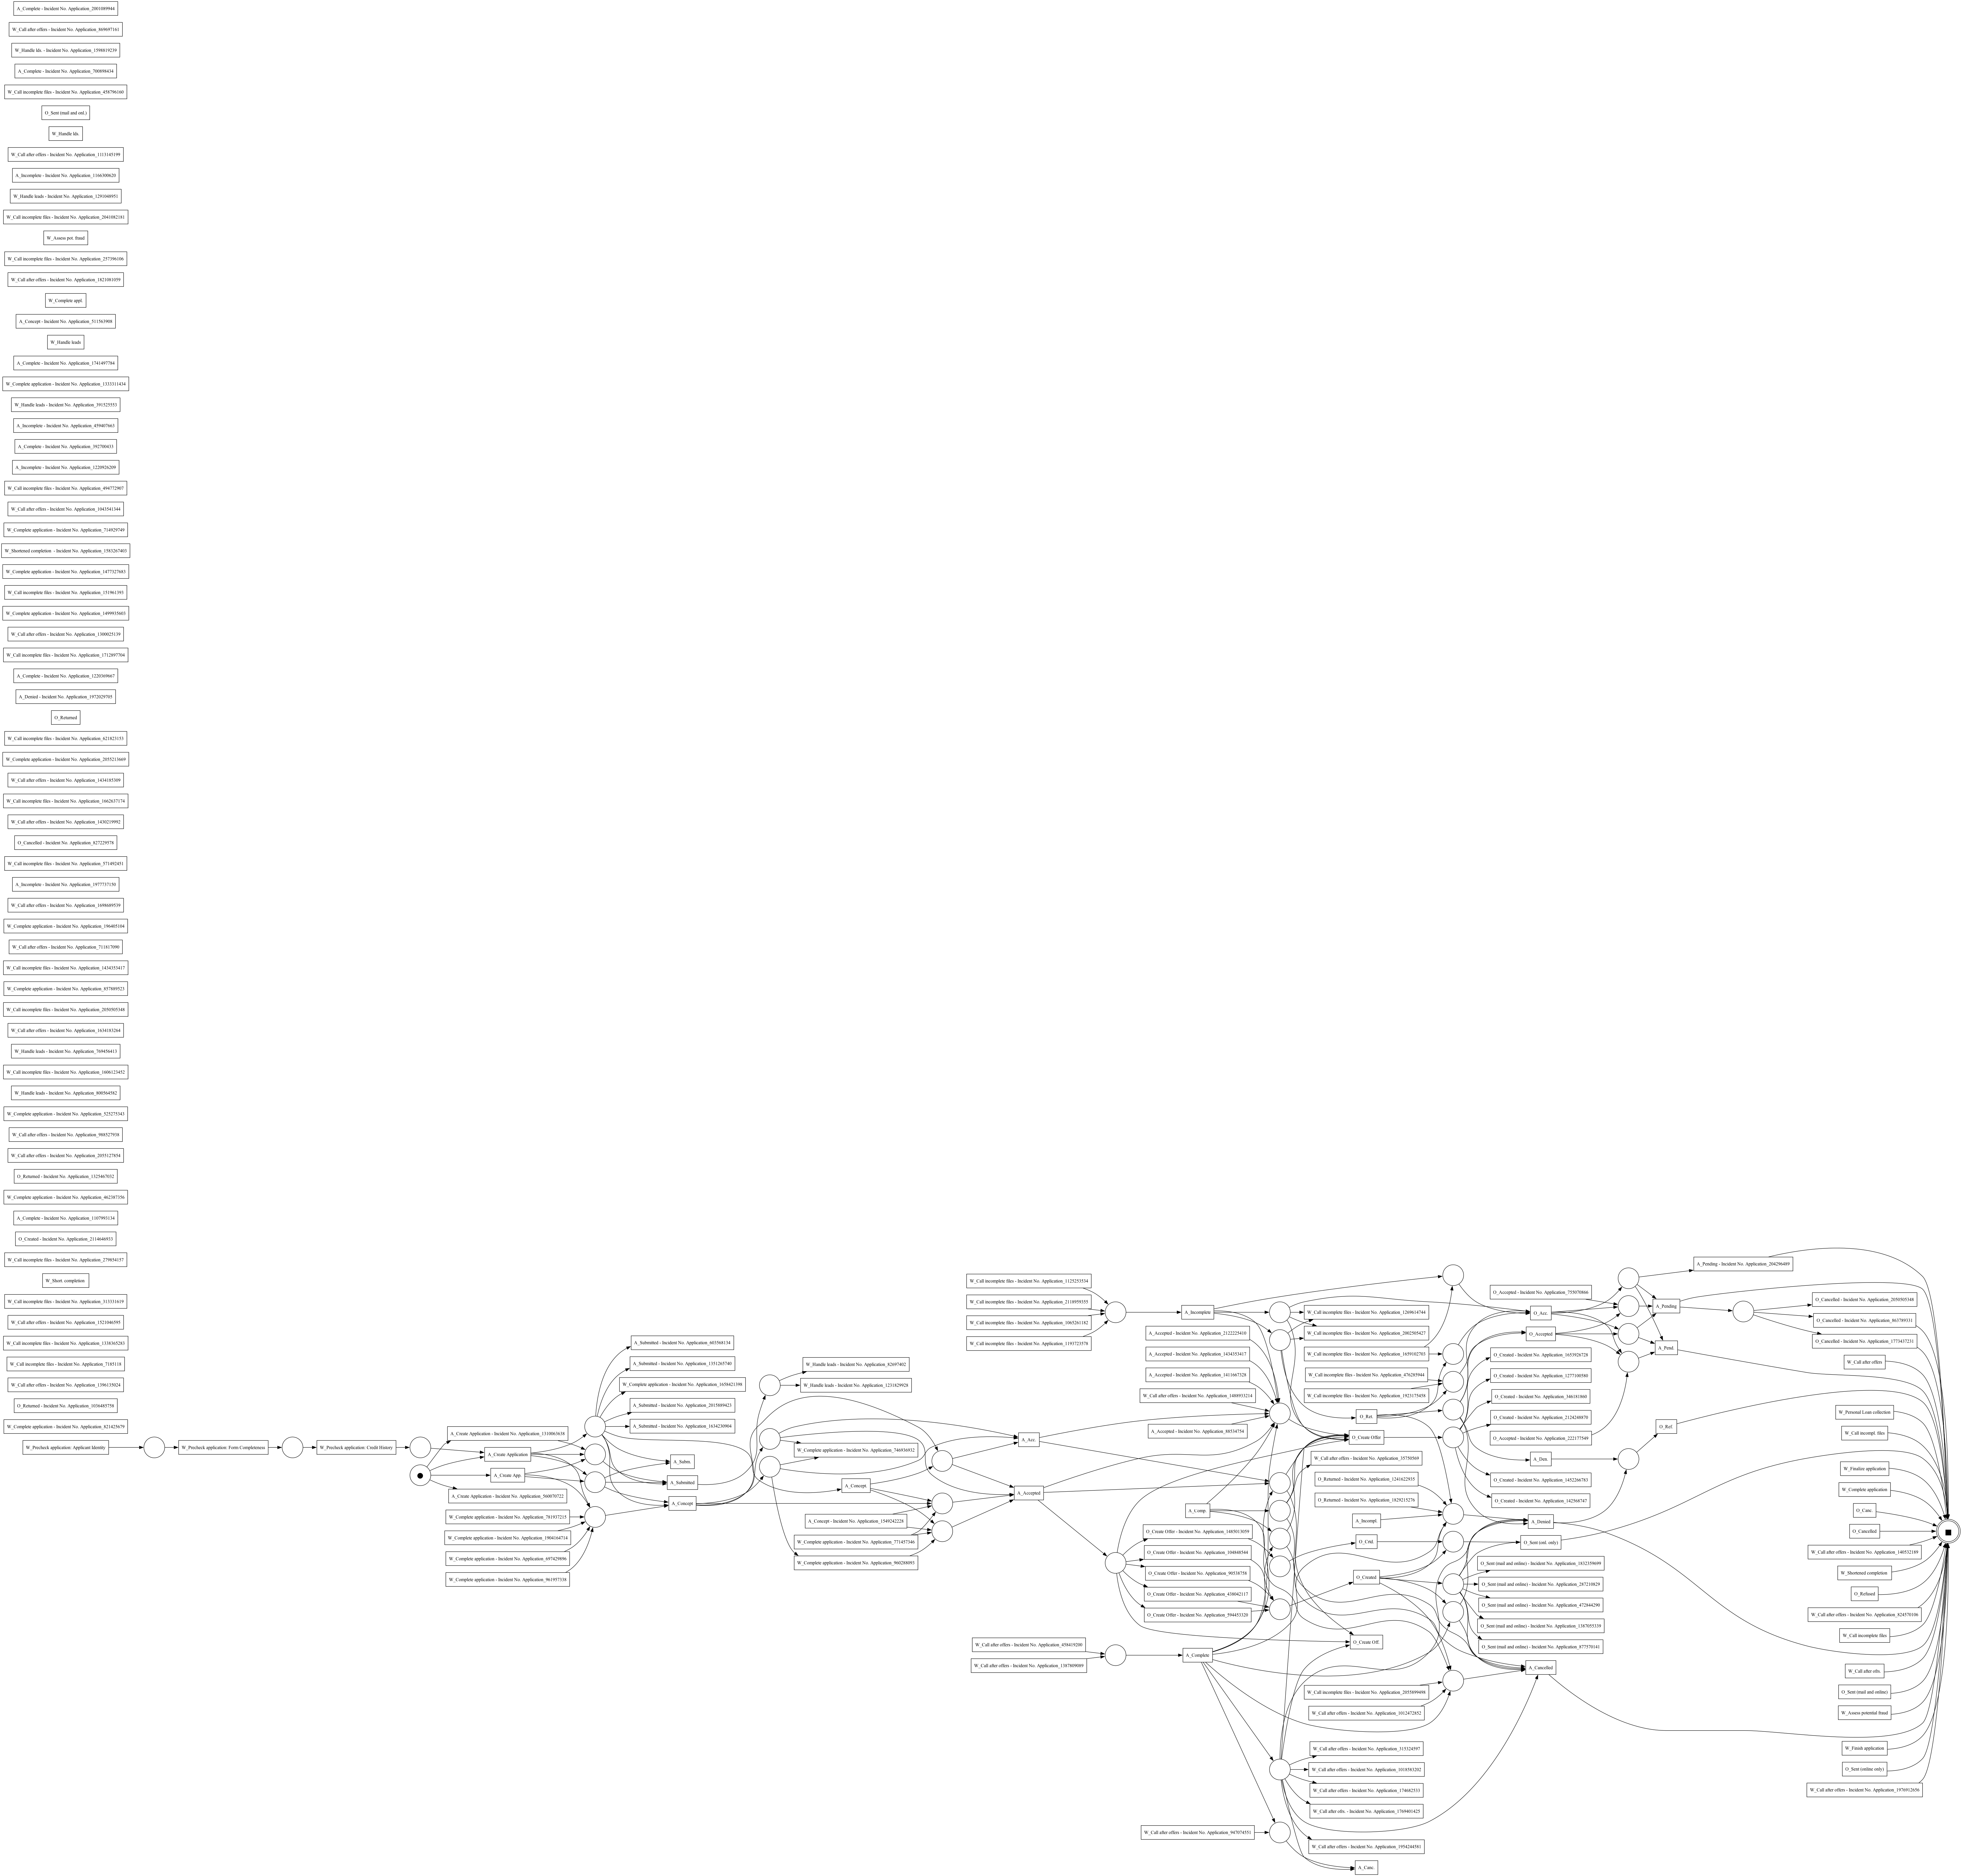

In [65]:
gviz_net_noised_sample = pn_visualizer.apply(net_noised_sample, im_noised_sample, fm_noised_sample)
pn_visualizer.view(gviz_net_noised_sample)

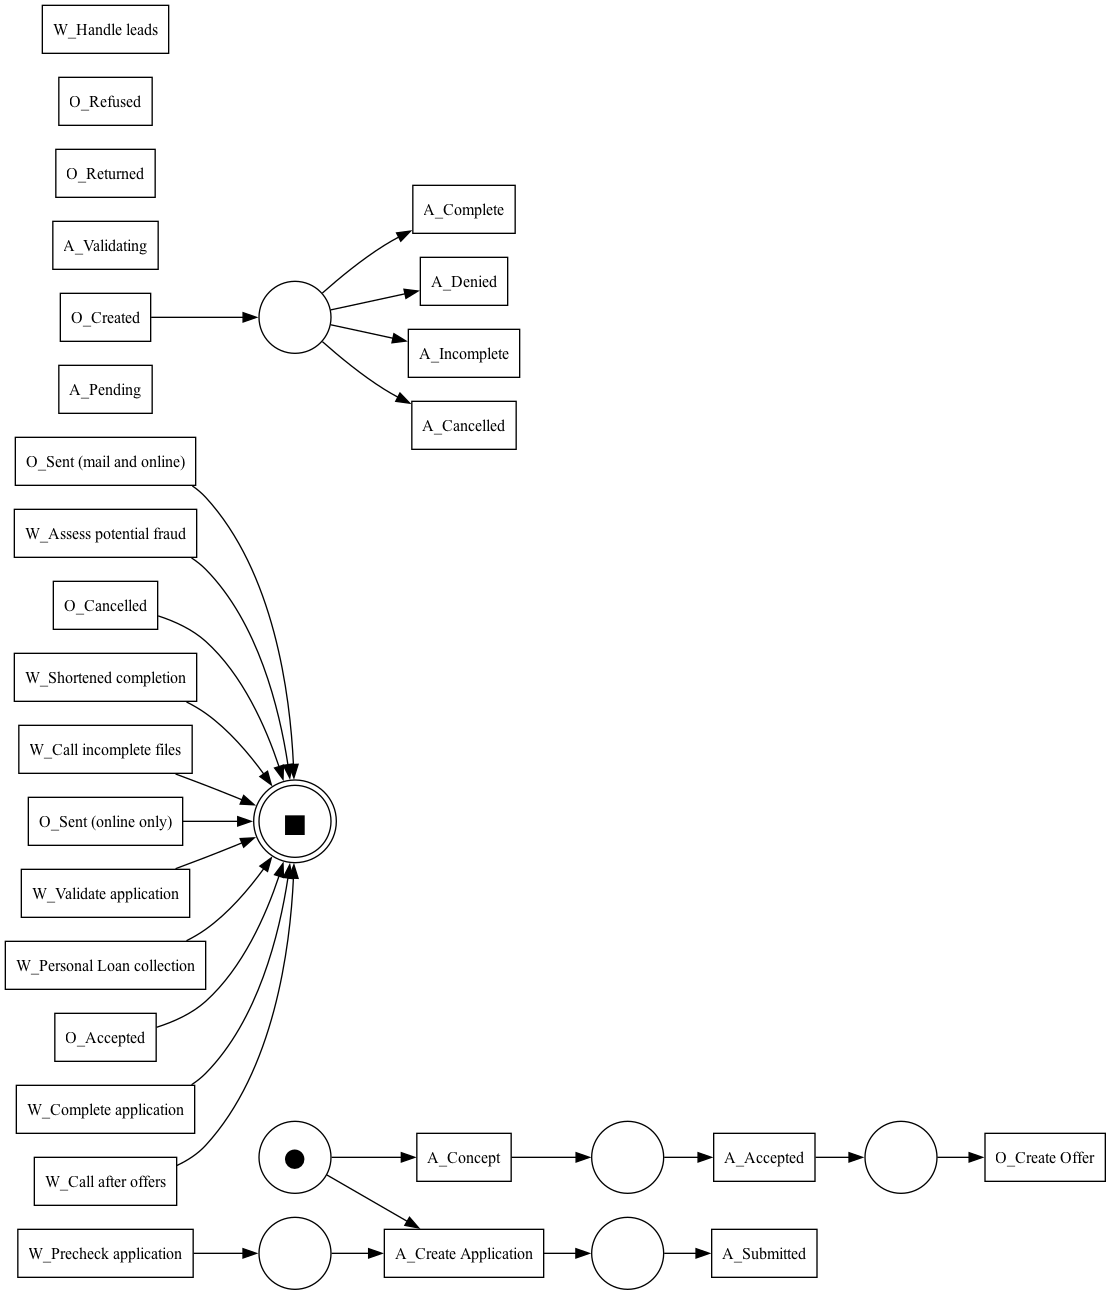

In [66]:
gviz_net_recovered_sample = pn_visualizer.apply(net_recovered_sample, im_recovered_sample, fm_recovered_sample)
pn_visualizer.view(gviz_net_recovered_sample)

In [67]:
print("Clean sample cases:", df_sample["case:concept:name"].nunique())
print("Noised sample cases:", df_noised_sample["case:concept:name"].nunique())
print("Recovered sample cases:", df_recovered_sample["case:concept:name"].nunique())

print("Clean activities:", df_sample["concept:name"].nunique())
print("Noised activities:", df_noised_sample["concept:name"].nunique())
print("Recovered activities:", df_recovered_sample["concept:name"].nunique())

Clean sample cases: 5000
Noised sample cases: 5000
Recovered sample cases: 5000
Clean activities: 26
Noised activities: 183
Recovered activities: 27


In [56]:
# just testing which sample size to use
for sample_size in [1000, 2000, 3000, 5000, 7500, 10000]:
    sample_case_ids = (
        df["case:concept:name"]
        .drop_duplicates()
        .sample(n=sample_size, random_state=42)
        .tolist()
    )

    df_noised_sample = df_noised[
        df_noised["case:concept:name"].isin(sample_case_ids)
    ].sort_values(["case:concept:name", "time:timestamp"])

    print("sample_size:", sample_size)
    print("events:", len(df_noised_sample))
    print("activities:", df_noised_sample["concept:name"].nunique())

    net_noised_sample, im_noised_sample, fm_noised_sample = alpha_miner.apply(df_noised_sample)

    print("places:", len(net_noised_sample.places))
    print("transitions:", len(net_noised_sample.transitions))
    print("arcs:", len(net_noised_sample.arcs))
    print()

sample_size: 1000
events: 30029
activities: 73
places: 27
transitions: 73
arcs: 109

sample_size: 2000
events: 60338
activities: 99
places: 28
transitions: 99
arcs: 130

sample_size: 3000
events: 90641
activities: 126
places: 36
transitions: 126
arcs: 175

sample_size: 5000
events: 150761
activities: 183
places: 44
transitions: 183
arcs: 233

sample_size: 7500
events: 226445
activities: 249


KeyboardInterrupt: 

In [68]:
def evaluate_model(log, net, initial_marking, final_marking, name):
    fitness = replay_fitness_evaluator.apply(
        log,
        net,
        initial_marking,
        final_marking,
        variant=replay_fitness_evaluator.Variants.TOKEN_BASED
    )

    precision = precision_evaluator.apply(
        log,
        net,
        initial_marking,
        final_marking
    )

    generalization = generalization_evaluator.apply(
        log,
        net,
        initial_marking,
        final_marking
    )

    simplicity = simplicity_evaluator.apply(net)

    return {
        "model": name,
        "fitness": fitness,
        "precision": precision,
        "generalization": generalization,
        "simplicity": simplicity,
        "places": len(net.places),
        "transitions": len(net.transitions),
        "arcs": len(net.arcs)
    }

In [69]:
results = [
    evaluate_model(
        df_sample,
        net_sample,
        im_sample,
        fm_sample,
        "Clean"
    ),
    evaluate_model(
        df_noised_sample,
        net_noised_sample,
        im_noised_sample,
        fm_noised_sample,
        "Noised"
    ),
    evaluate_model(
        df_recovered_sample,
        net_recovered_sample,
        im_recovered_sample,
        fm_recovered_sample,
        "Recovered"
    )
]

results

replaying log with TBR, completed traces ::   0%|          | 0/3142 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/54868 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3142 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/4697 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/83505 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/4697 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3214 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/57481 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3214 [00:00<?, ?it/s]

[{'model': 'Clean',
  'fitness': {'perc_fit_traces': 0.0,
   'average_trace_fitness': 0.41477337923595403,
   'log_fitness': 0.3994426482223561,
   'percentage_of_fitting_traces': 0.0},
  'precision': 0.09549975768341745,
  'generalization': 0.9661277834281566,
  'simplicity': 0.5384615384615384,
  'places': 16,
  'transitions': 26,
  'arcs': 60},
 {'model': 'Noised',
  'fitness': {'perc_fit_traces': 0.0,
   'average_trace_fitness': 0.41313981209380946,
   'log_fitness': 0.3998049664887116,
   'percentage_of_fitting_traces': 0.0},
  'precision': 0.025088071846779747,
  'generalization': 0.2561503207488508,
  'simplicity': 0.9497907949790795,
  'places': 44,
  'transitions': 183,
  'arcs': 233},
 {'model': 'Recovered',
  'fitness': {'perc_fit_traces': 0.0,
   'average_trace_fitness': 0.436636707062183,
   'log_fitness': 0.41781575002186067,
   'percentage_of_fitting_traces': 0.0},
  'precision': 0.052600018936006854,
  'generalization': 0.9488637914493361,
  'simplicity': 1.0,
  'places

In [70]:
dfg_sample, sa_sample, ea_sample = pm4py.discover_dfg(df_sample)
dfg_recovered_sample, sa_recovered_sample, ea_recovered_sample = pm4py.discover_dfg(df_recovered_sample)

print("Clean DFG edges:", len(dfg_sample))
print("Recovered DFG edges:", len(dfg_recovered_sample))

Clean DFG edges: 148
Recovered DFG edges: 158


### Explanation of results

In [71]:
footprints_sample = footprints_discovery.apply(df_sample)
footprints_noised_sample = footprints_discovery.apply(df_noised_sample)
footprints_recovered_sample = footprints_discovery.apply(df_recovered_sample)

print("Clean sequence:", len(footprints_sample["sequence"]))
print("Noised sequence:", len(footprints_noised_sample["sequence"]))
print("Recovered sequence:", len(footprints_recovered_sample["sequence"]))

print("Clean parallel:", len(footprints_sample["parallel"]))
print("Noised parallel:", len(footprints_noised_sample["parallel"]))
print("Recovered parallel:", len(footprints_recovered_sample["parallel"]))

Clean sequence: 66
Noised sequence: 411
Recovered sequence: 55
Clean parallel: 82
Noised parallel: 260
Recovered parallel: 110


In [72]:
clean_seq = footprints_sample["sequence"]
noised_seq = footprints_noised_sample["sequence"]
recovered_seq = footprints_recovered_sample["sequence"]

clean_par = footprints_sample["parallel"]
noised_par = footprints_noised_sample["parallel"]
recovered_par = footprints_recovered_sample["parallel"]

print("Noised added sequence relations:")
print(list(noised_seq - clean_seq)[:20])

print("Recovered removed noised sequence relations:")
print(list(noised_seq - recovered_seq)[:20])

print("Recovered missing clean sequence relations:")
print(list(clean_seq - recovered_seq)[:20])

print("Noised added parallel relations:")
print(list(noised_par - clean_par)[:20])

print("Recovered added parallel relations:")
print(list(recovered_par - clean_par)[:20])

Noised added sequence relations:
[('A_Accepted - Incident No. Application_1411667328', 'O_Create Offer'), ('O_Returned', 'O_Cancelled'), ('A_Concept.', 'A_Accepted'), ('O_Create Offer', 'O_Created - Incident No. Application_346181860'), ('O_Created', 'O_Sent (mail and online) - Incident No. Application_472844290'), ('O_Create Offer', 'O_Created - Incident No. Application_1653926728'), ('O_Create Offer - Incident No. Application_1485013059', 'O_Crtd.'), ('W_Finish application', 'O_Create Offer'), ('O_Accepted - Incident No. Application_755070866', 'A_Pending'), ('A_Accepted', 'O_Create Off.'), ('W_Call after offers', 'W_Call incomplete files'), ('W_Handle leads', 'W_Handle lds. - Incident No. Application_1598819239'), ('W_Handle leads - Incident No. Application_769456413', 'W_Finish application'), ('A_Acc.', 'O_Create Offer'), ('W_Complete application', 'A_Accepted - Incident No. Application_88534754'), ('W_Handle lds.', 'W_Handle leads - Incident No. Application_1291048951'), ('W_Call 

The evaluation shows that the noised log strongly distorts the α-Miner result. In the footprint matrix, the number of sequence relations increases from 66 in the clean log to 411 in the noised log, and the number of parallel relations increases from 82 to 260. Many of these additional cells are caused by polluted or distorted labels, e.g. relations involving variants such as "A_Acc.", "W_Handle lds.", or activity names extended with "Incident No. Application". Since the α-Algorithm treats every label as a separate activity and does not filter infrequent behavior, these artificial footprint cells are directly reflected in the mined model. This explains the strong decrease in precision and generalization for the noised model.

The recovered log removes many of these artificial noised relations. Its number of transitions decreases from 183 in the noised model to 27, close to the 26 transitions of the clean model. Consequently, generalization improves from 0.256 to 0.949. However, the recovered footprint matrix is not identical to the clean one. Some clean sequence relations, such as ("A_Pending", "W_Validate application") and ("A_Create Application", "A_Concept"), are missing as sequence relations in the recovered footprint. At the same time, some of these relations appear as additional parallel relations in the recovered footprint. This means that the recovery step changed the relation type from causality to parallelism for some activity pairs.

This also explains why the recovered model has fewer arcs than the clean model, even though the recovered DFG has slightly more edges. The α-Miner does not translate DFG edges directly into Petri-net arcs. It first classifies footprint relations into causality, parallelism, and choice. Only clear causal relations are used to construct places and arcs. Because the recovered footprint contains fewer sequence relations and more parallel relations than the clean footprint, the α-Miner creates a structurally simpler model with fewer arcs.

Overall, the recovered model is clearly closer to the clean model than the noised model, especially in terms of number of transitions and generalization. However, its lower precision and strongly reduced arc count show that the original clean footprint structure was not fully restored. This is consistent with the known limitations of the α-Algorithm: it is sensitive to noise, cannot filter rare behavior, and struggles with loops, non-free-choice constructs, and complex parallel behavior.